In [16]:
pip install river

Note: you may need to restart the kernel to use updated packages.


In [17]:
from river import datasets
from river import compose
from river import linear_model
from river import metrics
from river import preprocessing
from river import evaluate
from river import optim
import matplotlib.pyplot as plt
import pandas as pd

In [18]:
# 3. Charger le dataset streaming (Bikes de Toulouse – super pour online)
# ────────────────────────────────────────────────────────────────
dataset = datasets.Elec2()
print (dataset)

# Regarde à quoi ressemble un exemple (premier point du flux)
x, y = next(iter(dataset))
print("Exemple de point :", x)
print("Cible (nb vélos) :", y)

Electricity prices in New South Wales.

This is a binary classification task, where the goal is to predict if the price of electricity
will go up or down.

This data was collected from the Australian New South Wales Electricity Market. In this market,
prices are not fixed and are affected by demand and supply of the market. They are set every
five minutes. Electricity transfers to/from the neighboring state of Victoria were done to
alleviate fluctuations.

      Name  Elec2                                                      
      Task  Binary classification                                      
   Samples  45,312                                                     
  Features  8                                                          
    Sparse  False                                                      
      Path  C:\Users\afagn\river_data\Elec2\electricity.csv            
       URL  https://maxhalford.github.io/files/datasets/electricity.zip
      Size  2.95 MiB               

In [19]:
#  Construire un pipeline simple (préprocessing + modèle online)

model = compose.Pipeline(
    preprocessing.StandardScaler(),
    linear_model.PARegressor(
        C=0.01,              # Paramètre de régularisation (comme alpha en sklearn)
        mode=1,              # Mode 1 ou 2 (PA-I ou PA-II)
        eps=0.1,            
        learn_intercept=True
    )
)

In [20]:

# 5. Métriques à suivre en live
# ────────────────────────────────────────────────────────────────
mae = metrics.MAE()
rmse = metrics.RMSE()
r2 = metrics.R2()

# Liste pour stocker l'évolution (pour plot après)
mae_history = []
rmse_history = []
r2_history = []

In [21]:
# 6. Apprentissage progressif sur le flux (c'est le cœur de l'online !)
# ────────────────────────────────────────────────────────────────
n_samples = 0
for x, y in dataset:
    # Prédiction avant update
    y_pred = model.predict_one(x)
    
    # Mise à jour des métriques
    mae.update(y, y_pred)
    rmse.update(y, y_pred)
    r2.update(y, y_pred)
    
    # Apprentissage sur ce point (adaptation immédiate)
    model.learn_one(x, y)

    n_samples += 1
    
    # Sauvegarde tous les 100 points
    if n_samples % 100 == 0:
        mae_history.append(mae.get())
        rmse_history.append(rmse.get())
        r2_history.append(r2.get())
    
    
    
    n_samples += 1
    if n_samples % 1000 == 0:
        print(f"Après {n_samples} points → MAE: {mae.get():.4f} | RMSE: {rmse.get():.4f} | R²: {r2.get():.4f}")

Après 1000 points → MAE: 0.2440 | RMSE: 0.3628 | R²: 0.4697
Après 2000 points → MAE: 0.2328 | RMSE: 0.3345 | R²: 0.5523
Après 3000 points → MAE: 0.2084 | RMSE: 0.3152 | R²: 0.5850
Après 4000 points → MAE: 0.2103 | RMSE: 0.3148 | R²: 0.5857
Après 5000 points → MAE: 0.2227 | RMSE: 0.3244 | R²: 0.5632
Après 6000 points → MAE: 0.2259 | RMSE: 0.3241 | R²: 0.5628
Après 7000 points → MAE: 0.2287 | RMSE: 0.3242 | R²: 0.5678
Après 8000 points → MAE: 0.2177 | RMSE: 0.3152 | R²: 0.5855
Après 9000 points → MAE: 0.2146 | RMSE: 0.3126 | R²: 0.5904
Après 10000 points → MAE: 0.2141 | RMSE: 0.3105 | R²: 0.5945
Après 11000 points → MAE: 0.2137 | RMSE: 0.3090 | R²: 0.5992
Après 12000 points → MAE: 0.2167 | RMSE: 0.3110 | R²: 0.5950
Après 13000 points → MAE: 0.2177 | RMSE: 0.3103 | R²: 0.5976
Après 14000 points → MAE: 0.2173 | RMSE: 0.3099 | R²: 0.5991
Après 15000 points → MAE: 0.2199 | RMSE: 0.3122 | R²: 0.5956
Après 16000 points → MAE: 0.2220 | RMSE: 0.3135 | R²: 0.5950
Après 17000 points → MAE: 0.2214 


=== Résultats finaux ===
MAE  : 0.2517
RMSE : 0.3942
R²   : 0.3638


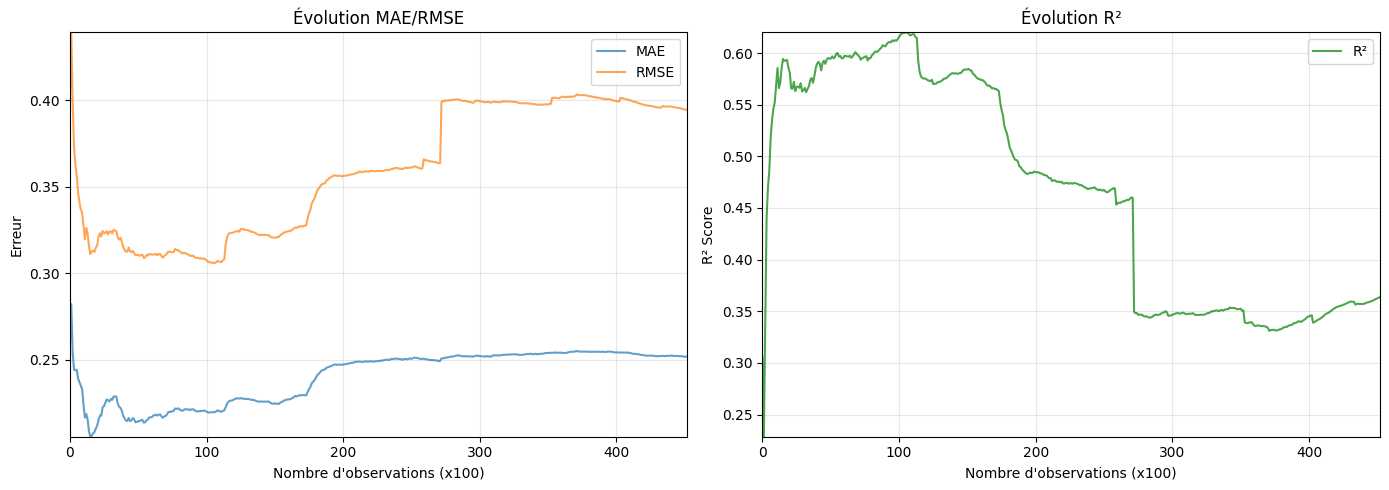

In [24]:
# Résultats finaux
print(f"\n=== Résultats finaux ===")
print(f"MAE  : {mae.get():.4f}")
print(f"RMSE : {rmse.get():.4f}")
print(f"R²   : {r2.get():.4f}")

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 : MAE et RMSE
ax1.plot(mae_history, label='MAE', alpha=0.7)
ax1.plot(rmse_history, label='RMSE', alpha=0.7)
ax1.set_xlabel("Nombre d'observations (x100)")
ax1.set_ylabel("Erreur")
ax1.set_title("Évolution MAE/RMSE")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.autoscale(enable=True, axis='both', tight=True) 

# Plot 2 : R²
ax2.plot(r2_history, color='green', alpha=0.7, label='R²')
ax2.set_xlabel("Nombre d'observations (x100)")
ax2.set_ylabel("R² Score")
ax2.set_title("Évolution R²")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.autoscale(enable=True, axis='both', tight=True)

plt.tight_layout()
plt.show()